# Lesson Overview

With this lesson, we return to the topic of using Pandas to deal with real-world data: normalizing data (aka "cleaning") and basic reporting and visualisation.

The lesson is divided into these parts:

- Data normalization
- Effective reporting and visualisation

## Statistical data normalization

Statistical data normalisation is the process of transforming numeric values to a common scale without distorting differences in the ranges of values.It helps ensure that features contribute equally to analysis and modelling, especially when they originally have very different units or scales. Normalisation is vital especially in machine learning algorithms that depend on distance, gradient or scale. e.g., clustering, neural networks

Consider the following features in a dataset about people.

- Age: 0–100
- Income: 0–200,000
- Distance: 0–500

If we use these directly in many algorithms, the feature with the largest scale dominates the calculations. Normalisation fixes this by putting everything on a comparable scale.

### Common normalisation techniques

- min-max scaling

  ### <div align="center">  $ x_{norm}=\frac{x-x_{min}}{x_{max}-x_{min}}$ </div>
   
- z-score (standard) scaling

  ### <div align="center">   $ z=\frac{x-\mu}{\sigma}$ </div>

- decimal scaling

   ### <div align="center">   $ x_{norm}=\frac{x}{10^j}$ </div>

- vector normalisation

   ### <div align="center">   $ x_{norm}=\frac{x}{||x||}$ </div>

In our context, data normalization refers to the process of transforming data into a common format and scale without distorting the differences in the ranges of values. This process is important because it ensures that data is consistent and can be easily compared and analysed.

Normalisation is carried out as part of data wrangling/pre-processing.

Next, let's look at some code that perform normalixation.


In [1]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Use 'wine dataset' that comes with sklearn

from sklearn.datasets import load_wine

import matplotlib.pyplot as plt 

import pandas as pd
import seaborn as sns

In [6]:
# Run below to extract dataset from package

data_wine = load_wine()
print(data_wine.data)
print(data_wine.target)
print(data_wine.feature_names)


[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


In [7]:

df_wine = pd.DataFrame( data_wine.data, columns=data_wine.feature_names)
df_wine.info()
df_wine.describe() 

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: float64(13)
m

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [8]:
# TODO: Write code to generate min, max, mean, std values on each column
result = df_wine.agg(['min', 'max', 'mean', 'std'])
print(result)

        alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
min   11.030000    0.740000  1.360000          10.600000   70.000000   
max   14.830000    5.800000  3.230000          30.000000  162.000000   
mean  13.000618    2.336348  2.366517          19.494944   99.741573   
std    0.811827    1.117146  0.274344           3.339564   14.282484   

      total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
min        0.980000    0.340000              0.130000         0.410000   
max        3.880000    5.080000              0.660000         3.580000   
mean       2.295112    2.029270              0.361854         1.590899   
std        0.625851    0.998859              0.124453         0.572359   

      color_intensity       hue  od280/od315_of_diluted_wines      proline  
min          1.280000  0.480000                      1.270000   278.000000  
max         13.000000  1.710000                      4.000000  1680.000000  
mean         5.058090  0.957449      

#### TODO: Choose 3 columns that have very different ranges. Name them and their ranges
1. *column1*
2. *column2*
3. *column3*

In [9]:
# TODO: 3 columns with different ranges name them and their ranges 
df_wine.agg({'alcohol':['min', 'max', 'mean', 'std'], 
                             'magnesium':['min', 'max', 'mean', 'std'],
                            'color_intensity':['min', 'max', 'mean', 'std']})

df_wine[['alcohol', 'magnesium', 'color_intensity']].describe()

,alcohol,magnesium,color_intensity
count,178.000000,178.000000,178.000000
mean,13.000618,99.741573,5.058090
std,0.811827,14.282484,2.318286
min,11.030000,70.000000,1.280000
25%,12.362500,88.000000,3.220000
50%,13.050000,98.000000,4.690000
75%,13.677500,107.000000,6.200000
max,14.830000,162.000000,13.000000


<Axes: >

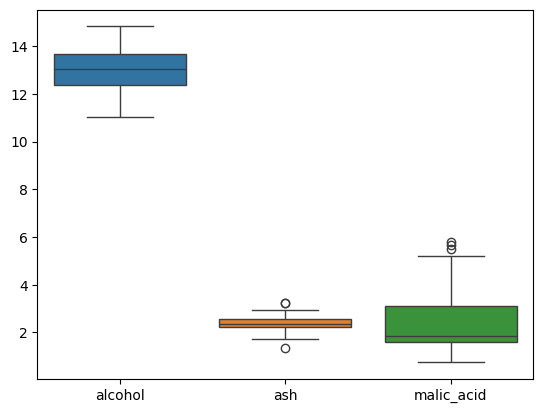

In [10]:
 # TODO: Plot histograms and boxplots for those 3 columns

sns.boxplot(data=df_wine[["alcohol", "ash", "malic_acid"]])


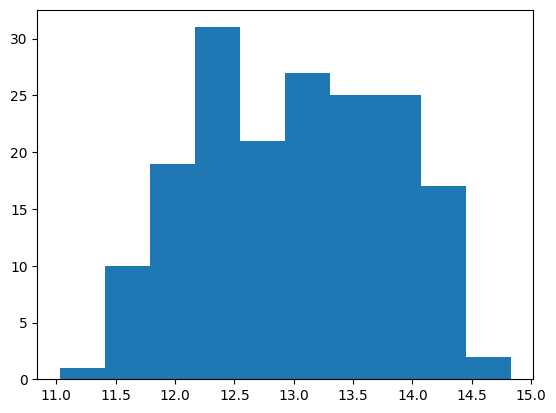

In [11]:
plt.hist(df_wine['alcohol'])
plt.show() 

## Let's standardise the 3 columns you chose using different techniques

In [12]:
df_chosen = df_wine[['alcohol', 'ash', 'magnesium']]
df_chosen.describe()

,alcohol,ash,magnesium
count,178.000000,178.000000,178.000000
mean,13.000618,2.366517,99.741573
std,0.811827,0.274344,14.282484
min,11.030000,1.360000,70.000000
25%,12.362500,2.210000,88.000000
50%,13.050000,2.360000,98.000000
75%,13.677500,2.557500,107.000000
max,14.830000,3.230000,162.000000


In [13]:
# TODO: min-max standardisation
#       save normalized DataFrame under a different name

df_chosen_zscore = (df_chosen - df_chosen.mean()) / df_chosen.std()
[df_chosen.describe(), df_chosen_zscore.describe()]

[          alcohol         ash   magnesium
 count  178.000000  178.000000  178.000000
 mean    13.000618    2.366517   99.741573
 std      0.811827    0.274344   14.282484
 min     11.030000    1.360000   70.000000
 25%     12.362500    2.210000   88.000000
 50%     13.050000    2.360000   98.000000
 75%     13.677500    2.557500  107.000000
 max     14.830000    3.230000  162.000000,
             alcohol           ash     magnesium
 count  1.780000e+02  1.780000e+02  1.780000e+02
 mean  -9.181170e-16 -8.070947e-16 -1.995907e-17
 std    1.000000e+00  1.000000e+00  1.000000e+00
 min   -2.427388e+00 -3.668813e+00 -2.082381e+00
 25%   -7.860275e-01 -5.705131e-01 -8.220960e-01
 50%    6.082829e-02 -2.375431e-02 -1.219377e-01
 75%    8.337767e-01  6.961448e-01  5.082048e-01
 max    2.253415e+00  3.147447e+00  4.359076e+00]

In [14]:
# TODO: Z-score standardisation

df_chosen_minmax = (df_chosen - df_chosen.min()) / (df_chosen.max() - df_chosen.min())
[df_chosen.describe(), df_chosen_minmax.describe()]

[          alcohol         ash   magnesium
 count  178.000000  178.000000  178.000000
 mean    13.000618    2.366517   99.741573
 std      0.811827    0.274344   14.282484
 min     11.030000    1.360000   70.000000
 25%     12.362500    2.210000   88.000000
 50%     13.050000    2.360000   98.000000
 75%     13.677500    2.557500  107.000000
 max     14.830000    3.230000  162.000000,
           alcohol         ash   magnesium
 count  178.000000  178.000000  178.000000
 mean     0.518584    0.538244    0.323278
 std      0.213639    0.146708    0.155244
 min      0.000000    0.000000    0.000000
 25%      0.350658    0.454545    0.195652
 50%      0.531579    0.534759    0.304348
 75%      0.696711    0.640374    0.402174
 max      1.000000    1.000000    1.000000]

In [15]:
# TODO: Re-write z-score normalisation using apply( ) and lambda functions
# df_chosen_zscore = (df_chosen - df_chosen.mean()) / df_chosen.std()
# [df_chosen.describe(), df_chosen_zscore.describe()]

df_chosen_zscore = df_chosen.apply(
    lambda col: (col - col.mean()) / col.std()
)
df_chosen_zscore

,alcohol,ash,magnesium
0,1.514341,0.231400,1.908522
1,0.245597,-0.825667,0.018094
2,0.196325,1.106214,0.088110
3,1.686791,0.486554,0.928300
4,0.294868,1.835226,1.278379
...,...,...,...
173,0.873810,0.304301,-0.331985
174,0.491955,0.413653,0.158126
175,0.331822,-0.388260,1.418411
176,0.208643,0.012696,1.418411


In [16]:
# TODO: Re-write z-score normalisation using apply( ) and lambda functions
#        compare the results with results from cell above and verify that it gives the same results
# df_chosen_minmax = (df_chosen - df_chosen.min()) / (df_chosen.max() - df_chosen.min())
# [df_chosen.describe(), df_chosen_minmax.describe()]

# Wrong - find out why 
# df_chosen_minmax = lambda df_chosen: (df_chosen - df_chosen.min()) / (df_chosen.max() - df_chosen.min()) 
# df_chosen_minmax(df_chosen) 


df_chosen_minmax = df_chosen.apply(
    lambda col: (col - col.min()) / (col - col.max())
) 
df_chosen_minmax

,alcohol,ash,magnesium
0,-5.333333,-1.337500,-1.628571
1,-1.331288,-0.715596,-0.483871
2,-1.275449,-2.339286,-0.508197
3,-7.260870,-1.561644,-0.877551
4,-1.389937,-4.194444,-1.090909
...,...,...,...
173,-2.392857,-1.397436,-0.373134
174,-1.657343,-1.493333,-0.533333
175,-1.435897,-0.927835,-1.190476
176,-1.289157,-1.174419,-1.190476


In [17]:
# TODO: vector normalisation
#       Refer to equation and write the code
# from sklearn.datasets import load_wine
from sklearn.preprocessing import normalize 
import numpy as np 
df_vector_norm = pd.DataFrame(
    normalize(df_chosen, norm='l2'), 
    columns=df_chosen.columns
)
df_vector_norm 

# # Lambda function 
# df_vector_norm = df_chosen.apply(
#     lambda row: row / np.sqrt((row**2).sum()), axis=1
# )

# df_vector_norm = df_chosen.div(
#     np.sqrt((df_chosen**2).sum(axis=1)), axis=0)
# df_vector_norm

,alcohol,ash,magnesium
0,0.111330,0.019011,0.993602
1,0.130835,0.021211,0.991177
2,0.129160,0.026205,0.991277
3,0.126122,0.021942,0.991772
4,0.111471,0.024163,0.993474
...,...,...,...
173,0.142790,0.025517,0.989424
174,0.130216,0.024100,0.991193
175,0.109894,0.018716,0.993767
176,0.109074,0.019628,0.993840


<Axes: >

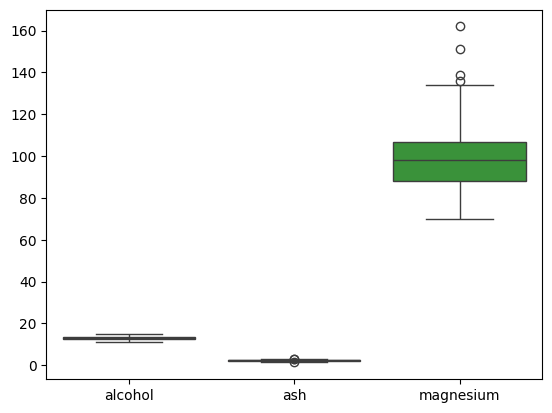

In [18]:
# TODO: Column1: generate boxplots and histograms comparing 
#       the results from the 3 techniques against original
sns.boxplot(data=df_chosen[["alcohol", "ash", "magnesium"]])

C:\Users\WANGMK\AppData\Local\Temp\ipykernel_15472\3925383946.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


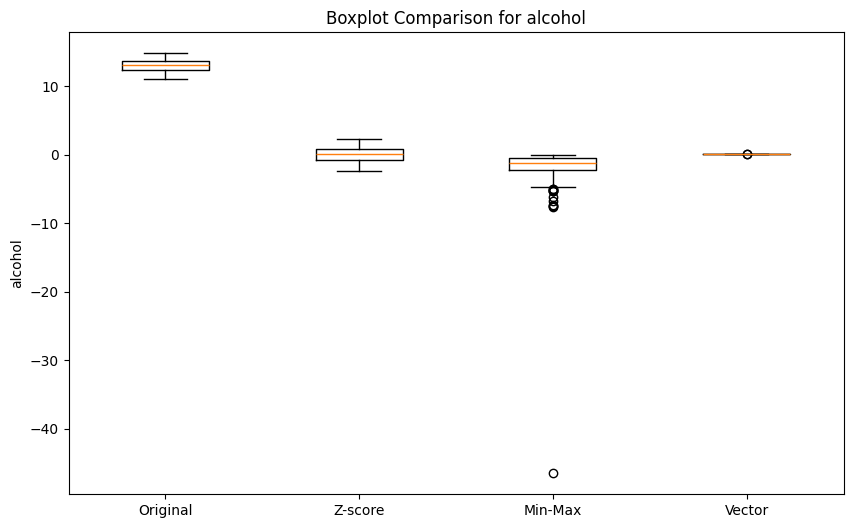

C:\Users\WANGMK\AppData\Local\Temp\ipykernel_15472\3925383946.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


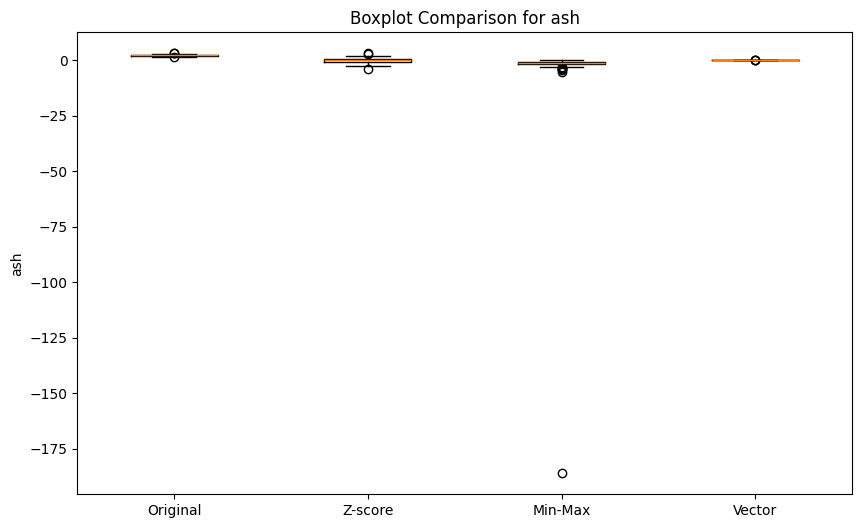

C:\Users\WANGMK\AppData\Local\Temp\ipykernel_15472\3925383946.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


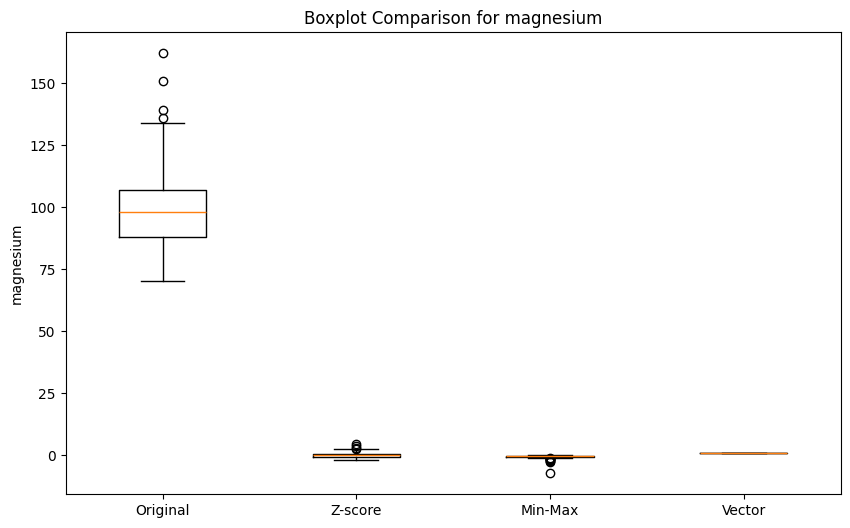

In [19]:
datasets = {
    'Original': df_chosen,
    'Z-score': df_chosen_zscore,
    'Min-Max': df_chosen_minmax,
    'Vector': df_vector_norm
}

for col in df_chosen.columns:
    plt.figure(figsize=(10, 6))
    plt.title(f'Boxplot Comparison for {col}')
    
    plt.boxplot(
        [datasets[name][col] for name in datasets],
        labels=datasets.keys()
    )
    
    plt.ylabel(col)
    plt.show()

In [20]:
# TODO: Column2: generate boxplots and histograms comparing 
#       the results from the 3 techniques against original

In [21]:
# for col in df_chosen.columns:
#     plt.figure(figsize=(10, 6))
#     plt.title(f'Histogram Comparison for {col}')
    
#     for name in datasets:
#         plt.hist(
#             datasets[name][col],
#             bins=20,
#             alpha=0.5,
#             label=name
#         )
    
#     plt.xlabel(col)
#     plt.ylabel('Frequency')
#     plt.legend()
#     plt.show()

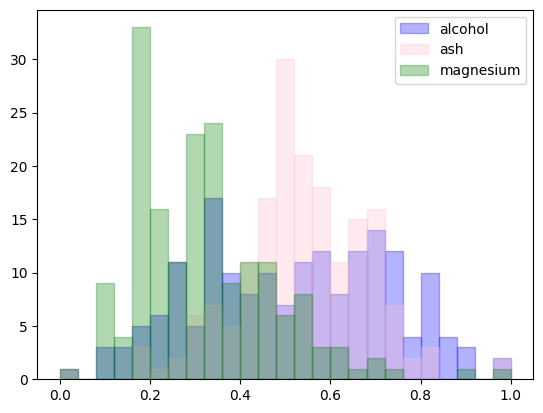

<Axes: >

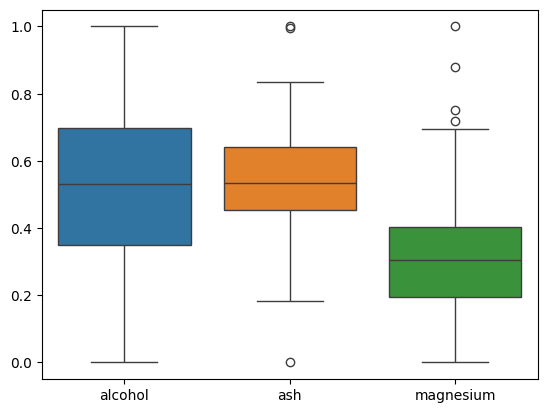

In [26]:
# TODO: Column3: generate boxplots and histograms comparing 
#       the results from the 3 techniques against original

df_chosen_minmax = (df_chosen - df_chosen.min()) / (df_chosen.max() - df_chosen.min())
plt.hist(df_chosen_minmax['alcohol'], bins = 25, alpha = 0.3, edgecolor='blue', color='blue')
plt.hist(df_chosen_minmax['ash'], bins = 25, alpha = 0.3, edgecolor='pink', color='pink')
plt.hist(df_chosen_minmax['magnesium'], bins = 25, alpha = 0.3, edgecolor='green', color='green')
plt.legend(['alcohol', 'ash', 'magnesium'])
plt.show()
 
sns.boxplot(df_chosen_minmax)

#### TODO: 
Describe your observations before and after normalisation.